In [5]:
import sys
sys.path.insert(0, "../build/")   #  relatif path to the build/ folder containing my .so for the cpp module
import pricing_engine as pe
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [18]:
option = pe.EuropeanOption(200, 0.9, pe.OptionType.Put)
market = pe.MarketData(200, 0.1, 0.04)
price = pe.price(option, market);
print(f"Call price: {price.price:.4f}")
print(f"Delta: {price.delta:.4f}  Gamma: {price.gamma:.4f}  Vega: {price.vega:.4f}")
print(f"Theta: {price.theta:.4f}  Rho: {price.rho:.4f}")

Call price: 4.4252
Delta: -0.3347  Gamma: 0.0192  Vega: 69.1013
Theta: -0.9842  Rho: -64.2329


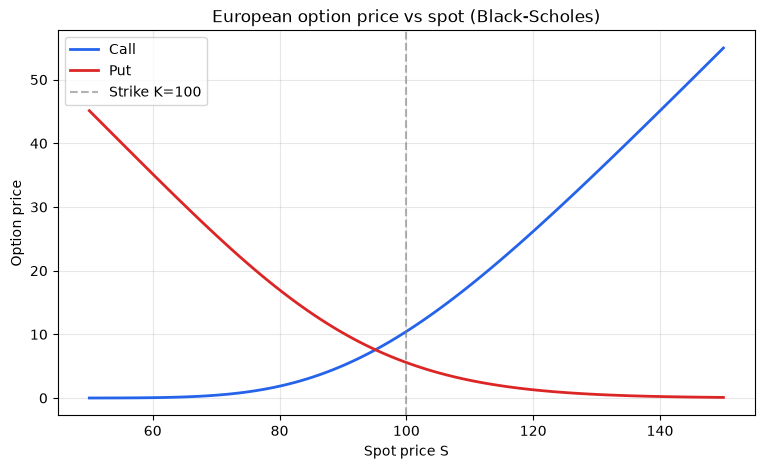

In [19]:
spots = np.linspace(50, 150, 100)
K = 100 #strike
call_prices = []
put_prices = []
for S in spots:
    market = pe.MarketData(S, 0.2, 0.05)
    call = pe.EuropeanOption(K, 1.0, pe.OptionType.Call)
    put  = pe.EuropeanOption(K, 1.0, pe.OptionType.Put)
    call_prices.append(pe.price(call, market).price)
    put_prices.append(pe.price(put, market).price)


plt.figure(figsize=(9, 5))
plt.plot(spots, call_prices, label="Call", color="#2563eb", linewidth=2)
plt.plot(spots, put_prices,  label="Put",  color="#dc2626", linewidth=2)
plt.axvline(K, color="gray", linestyle="--", alpha=0.6, label=f"Strike K={K}")
plt.xlabel("Spot price S")
plt.ylabel("Option price")
plt.title("European option price vs spot (Black-Scholes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()